Sprint 5 – Inferential Statistics

In [1]:
# ==========================================================
# Sprint 5: Inferential Statistics
# Consumer Insights Analytics
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Tests
from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    f_oneway,
    pearsonr,
    sem,
    t
)

# Optional: Import scipy.stats namespace
import scipy.stats as stats

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [3]:
from pathlib import Path

for file in Path("../data/raw").iterdir():
    print(file.name)

campaigns.csv
campaign_exposure.csv
customers.csv
survey_responses.csv


In [7]:
import pandas as pd

customers = pd.read_csv("../data/raw/customers.csv")
survey = pd.read_csv("../data/raw/survey_responses.csv")
campaigns = pd.read_csv("../data/raw/campaigns.csv")
exposure = pd.read_csv("../data/raw/campaign_exposure.csv")

In [8]:
print(customers.shape)
print(survey.shape)
print(campaigns.shape)
print(exposure.shape)

(15000, 9)
(15000, 12)
(5, 3)
(15000, 5)


In [9]:
customers.head()

,Customer_ID,Age,Gender,City,Region,Education,Occupation,Income_Bracket,Customer_Segment
0,CUST00001,19,Female,Surat,West,Diploma,Government Employee,Medium,Regular
1,CUST00002,55,Male,Ahmedabad,West,High School,Business Owner,Low,Regular
2,CUST00003,63,Female,Chennai,South,Bachelor,Business Owner,Medium,New
3,CUST00004,28,Female,Mumbai,West,Diploma,Government Employee,Low,Regular
4,CUST00005,23,Male,Surat,West,Bachelor,Healthcare Professional,Medium,Premium


In [10]:
survey.head()

,Survey_ID,Customer_ID,Survey_Date,Brand_Awareness,Brand_Recall,Brand_Preference,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand,Purchase_Intent
0,SURV00001,CUST00001,2025-08-17,Yes,ValueHub,NovaMart,4,3,4,4,9,High
1,SURV00002,CUST00002,2025-09-05,Yes,ValueHub,UrbanCart,5,4,4,4,9,High
2,SURV00003,CUST00003,2025-05-11,Yes,MegaMart,UrbanCart,4,4,3,4,7,High
3,SURV00004,CUST00004,2025-05-24,Yes,MegaMart,UrbanCart,3,4,4,4,7,High
4,SURV00005,CUST00005,2025-01-01,Yes,NovaMart,UrbanCart,2,1,1,1,3,Very Low


In [11]:
customers.columns.tolist()

['Customer_ID',
 'Age',
 'Gender',
 'City',
 'Region',
 'Education',
 'Occupation',
 'Income_Bracket',
 'Customer_Segment']

In [12]:
survey.columns.tolist()

['Survey_ID',
 'Customer_ID',
 'Survey_Date',
 'Brand_Awareness',
 'Brand_Recall',
 'Brand_Preference',
 'Product_Quality',
 'Service_Quality',
 'Value_for_Money',
 'Customer_Satisfaction',
 'Recommend_Brand',
 'Purchase_Intent']

In [13]:
df = customers.merge(
    survey,
    on="Customer_ID",
    how="inner"
)

df.head()

,Customer_ID,Age,Gender,City,Region,Education,Occupation,Income_Bracket,Customer_Segment,Survey_ID,Survey_Date,Brand_Awareness,Brand_Recall,Brand_Preference,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand,Purchase_Intent
0,CUST00001,19,Female,Surat,West,Diploma,Government Employee,Medium,Regular,SURV00001,2025-08-17,Yes,ValueHub,NovaMart,4,3,4,4,9,High
1,CUST00002,55,Male,Ahmedabad,West,High School,Business Owner,Low,Regular,SURV00002,2025-09-05,Yes,ValueHub,UrbanCart,5,4,4,4,9,High
2,CUST00003,63,Female,Chennai,South,Bachelor,Business Owner,Medium,New,SURV00003,2025-05-11,Yes,MegaMart,UrbanCart,4,4,3,4,7,High
3,CUST00004,28,Female,Mumbai,West,Diploma,Government Employee,Low,Regular,SURV00004,2025-05-24,Yes,MegaMart,UrbanCart,3,4,4,4,7,High
4,CUST00005,23,Male,Surat,West,Bachelor,Healthcare Professional,Medium,Premium,SURV00005,2025-01-01,Yes,NovaMart,UrbanCart,2,1,1,1,3,Very Low


In [14]:
print("Rows, Columns :", df.shape)

df.info()

Rows, Columns : (15000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_ID            15000 non-null  str  
 1   Age                    15000 non-null  int64
 2   Gender                 15000 non-null  str  
 3   City                   15000 non-null  str  
 4   Region                 15000 non-null  str  
 5   Education              15000 non-null  str  
 6   Occupation             15000 non-null  str  
 7   Income_Bracket         15000 non-null  str  
 8   Customer_Segment       15000 non-null  str  
 9   Survey_ID              15000 non-null  str  
 10  Survey_Date            15000 non-null  str  
 11  Brand_Awareness        15000 non-null  str  
 12  Brand_Recall           15000 non-null  str  
 13  Brand_Preference       15000 non-null  str  
 14  Product_Quality        15000 non-null  int64
 15  Service_Quality    

In [15]:
df.describe()

,Age,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,41.57,3.30,2.83,2.61,2.91,5.80
std,13.88,0.93,1.16,1.17,1.03,2.17
min,18.00,1.00,1.00,1.00,1.00,1.00
25%,30.00,3.00,2.00,2.00,2.00,4.00
50%,42.00,3.00,3.00,3.00,3.00,6.00
75%,54.00,4.00,4.00,3.00,4.00,7.00
max,65.00,5.00,5.00,5.00,5.00,10.00


Hypothesis Testing
Null Hypothesis (H₀)

There is no significant difference between the groups.

Alternative Hypothesis (H₁)

There is a significant difference between the groups.

Decision Rule

If p-value < 0.05

Reject H₀

Otherwise

Fail to Reject H₀

Independent t-Test
Business Question

Does customer satisfaction differ between males and females?

In [16]:
male = df[df["Gender"]=="Male"]["Customer_Satisfaction"]

female = df[df["Gender"]=="Female"]["Customer_Satisfaction"]

In [17]:
t_stat, p = ttest_ind(male, female)

print("T Statistic :", round(t_stat,3))
print("P-value :", round(p,4))

T Statistic : -0.17
P-value : 0.8651


In [18]:
if p < 0.05:
    print("Reject Null Hypothesis")
    print("Customer satisfaction differs by gender.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference found.")

Fail to Reject Null Hypothesis
No significant difference found.


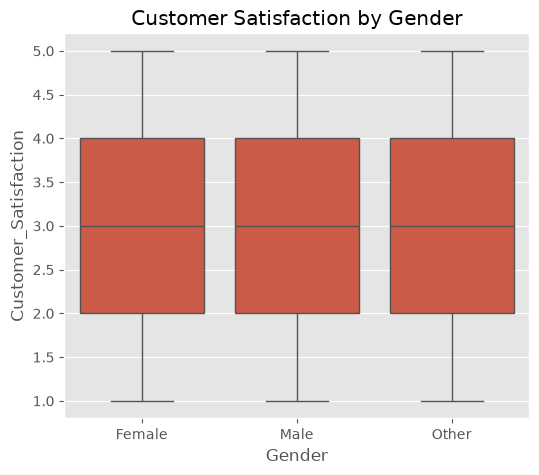

In [19]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Gender",
    y="Customer_Satisfaction",
    data=df
)

plt.title("Customer Satisfaction by Gender")

plt.show()

Chi-Square Test
Business Question

Is Purchase Intent associated with Gender?

In [20]:
table = pd.crosstab(
    df["Gender"],
    df["Purchase_Intent"]
)

table

Purchase_Intent,High,Low,Medium,Very High,Very Low
Gender,,,,,
Female,1666,1953,2604,425,604
Male,1671,2030,2677,449,611
Other,74,85,112,20,19


In [21]:
chi2,p,dof,expected = chi2_contingency(table)

print("Chi Square :", round(chi2,3))
print("P-value :", round(p,4))

Chi Square : 2.862
P-value : 0.9427


In [22]:
chi2,p,dof,expected = chi2_contingency(table)

print("Chi Square :", round(chi2,3))
print("P-value :", round(p,4))

Chi Square : 2.862
P-value : 0.9427


In [23]:
if p < 0.05:
    print("Purchase Intent depends on Gender.")
else:
    print("Purchase Intent is independent of Gender.")

Purchase Intent is independent of Gender.


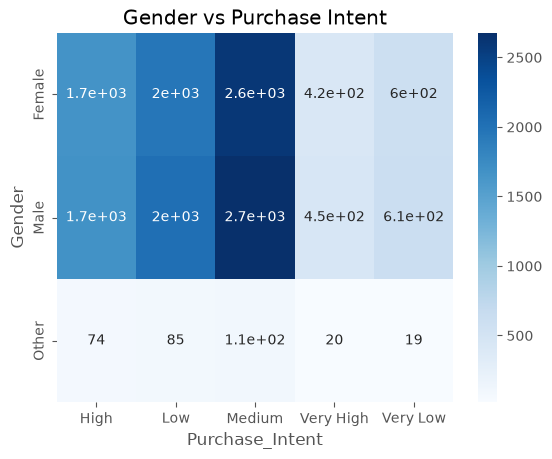

In [24]:
sns.heatmap(
    table,
    annot=True,
    cmap="Blues"
)

plt.title("Gender vs Purchase Intent")

plt.show()

ANOVA
Business Question

Do different regions have different customer satisfaction?

In [25]:
groups = []

for region in df["Region"].unique():
    groups.append(
        df[df["Region"]==region]["Customer_Satisfaction"]
    )

f,p = f_oneway(*groups)

print("F Statistic :", round(f,3))
print("P-value :", round(p,4))

F Statistic : 0.59
P-value : 0.6215


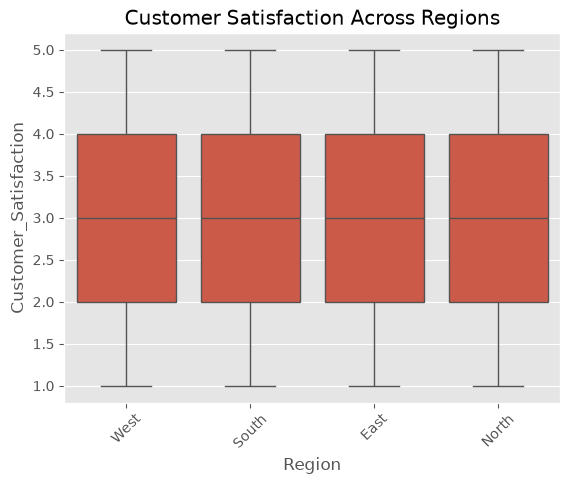

In [26]:
sns.boxplot(
    x="Region",
    y="Customer_Satisfaction",
    data=df
)

plt.xticks(rotation=45)

plt.title("Customer Satisfaction Across Regions")

plt.show()

Correlation Analysis

In [27]:
corr = df[[
    "Product_Quality",
    "Service_Quality",
    "Value_for_Money",
    "Customer_Satisfaction"
]].corr()

corr

,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction
Product_Quality,1.00,0.73,0.67,0.84
Service_Quality,0.73,1.00,0.71,0.88
Value_for_Money,0.67,0.71,1.00,0.86
Customer_Satisfaction,0.84,0.88,0.86,1.00


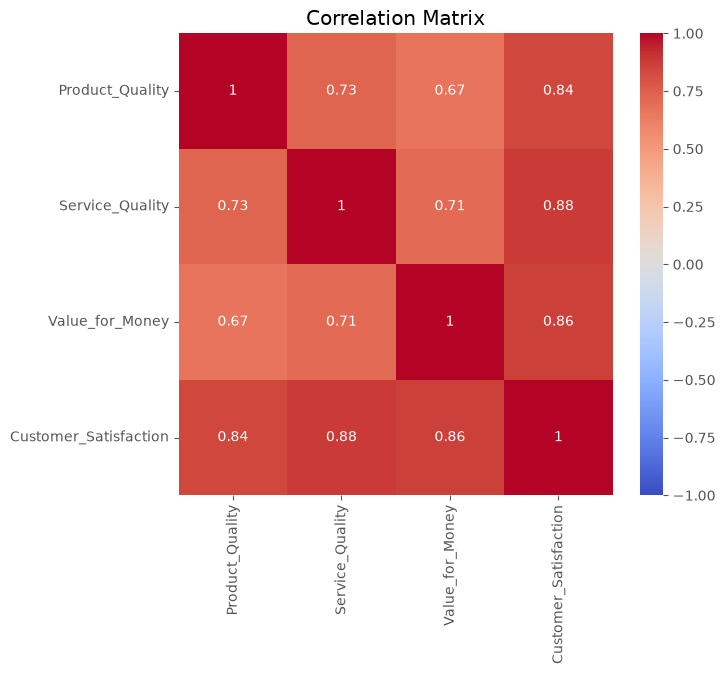

In [28]:
plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")

plt.show()

Confidence Interval

In [29]:
mean = df["Customer_Satisfaction"].mean()

interval = t.interval(
    confidence=0.95,
    df=len(df)-1,
    loc=mean,
    scale=sem(df["Customer_Satisfaction"])
)

print("Mean :", round(mean,2))
print("95% Confidence Interval :", interval)

Mean : 2.91
95% Confidence Interval : (np.float64(2.8944032548970506), np.float64(2.927330078436283))


Business Interpretation

• The Independent t-test evaluates whether customer satisfaction differs between male and female customers.

• The Chi-Square test determines whether gender influences purchase intent.

• ANOVA checks whether customer satisfaction varies significantly across different regions.

• Correlation analysis identifies the strongest factors influencing customer satisfaction.

• Confidence intervals estimate the range in which the true average customer satisfaction is expected to lie.

Sprint 5 Summary

✔ Performed hypothesis testing.

✔ Conducted Independent t-Test.

✔ Performed Chi-Square Test.

✔ Compared customer satisfaction across regions using ANOVA.

✔ Analyzed relationships using Pearson Correlation.

✔ Calculated 95% Confidence Interval.

✔ Converted statistical findings into business insights.